# Stage 7, Part 1: Neural Network From Scratch (NumPy, No Autograd)

**Goal:** build a 2-layer neural network — forward propagation, loss, and full backpropagation — entirely in raw NumPy, understanding every gradient computation by hand before ever letting a framework do it automatically.

**Scope decision:** this is BINARY classification ("is this digit a 3, yes or no"), not full 10-digit classification. This lets you extend directly from logistic regression's sigmoid + binary cross-entropy, while focusing entirely on the one genuinely new concept: **backpropagation through a hidden layer**. Full multi-class MNIST comes in Part 2, using PyTorch.

**Architecture:** input (784 pixels) → hidden layer (ReLU activation) → output (1 neuron, sigmoid activation) → probability the digit is a 3.

## 1. Load MNIST and prepare a binary target

**Syntax note:** `sklearn.datasets.fetch_openml('mnist_784', version=1)` downloads the classic MNIST dataset (70,000 handwritten digit images, 28x28 pixels flattened to 784 features each) directly from OpenML's public repository. It's cached locally after the first download, so subsequent runs are fast.

Guiding questions:
- Pixel values range 0-255. Given what you know about why gradient descent needs scaled features (Stage 4), why might dividing all pixel values by 255 (squashing them to a 0-1 range) matter here?
- Create a binary target: 1 if the digit is a 3, 0 otherwise. What fraction of the dataset is class 1? Is this imbalanced enough to need Stage 6's techniques, or closer to Titanic's manageable imbalance?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# TODO: fetch_openml('mnist_784', version=1, as_frame=False) -- as_frame=False gives you numpy arrays directly
# this returns an object with .data (the pixel arrays) and .target (the digit labels, as strings '0'-'9')

data_object = fetch_openml('mnist_784', version=1, as_frame=False)



In [2]:
# Scale pixels to 0-1
X = data_object.data / 255.0

# 1 = digit is '3'
# 0 = digit is not '3'
y = (data_object.target == "3").astype(int)

# Check class balance
print("Not 3:", (y == 0).sum())
print("3:", (y == 1).sum())

Not 3: 62859
3: 7141


## 2. Look at some actual digits

Before building anything, look at what you're actually working with. Each row is a flattened 784-length vector — reshape it back to 28x28 to visualize.

**Syntax note:** `plt.imshow(image.reshape(28, 28), cmap='gray')` reshapes a flat 784-vector back into its original 2D image grid for display.

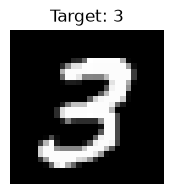

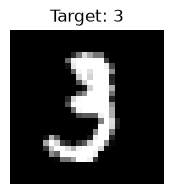

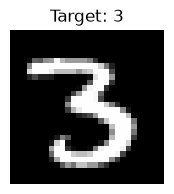

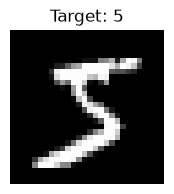

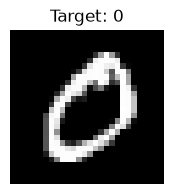

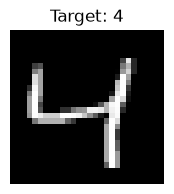

In [3]:
# TODO: plot a few example images (some 3s, some non-3s) using plt.imshow, labeled with their target value

# Plot a few example images
# Find indices of 3s and non-3s
three_indices = np.where(data_object.target == "3")[0]
non_three_indices = np.where(data_object.target != "3")[0]

# Select a few of each
indices = list(three_indices[:3]) + list(non_three_indices[:3])

for i in indices:
    plt.figure(figsize=(2, 2))
    plt.imshow(data_object.data[i].reshape(28, 28), cmap="gray")
    plt.title(f"Target: {data_object.target[i]}")
    plt.axis("off")
    plt.show()


## 3. Split and subset

Full-batch gradient descent (computing gradients over the ENTIRE training set on every iteration, which is what you'll build here) is simplest to reason about but can be slow with 70,000 images. Subset to a manageable size for this from-scratch exercise — e.g., 10,000 training examples — you're not trying to win a Kaggle competition here, you're trying to see backprop work correctly.

Same leakage rule as always: split first.

In [43]:
# TODO: stratified split into train/val, then subset X_train/y_train down to ~10,000 examples (stratified sample, or just slice after shuffling)

from sklearn.model_selection import train_test_split

X = data_object.data

y = (data_object.target == "3").astype(float).reshape(-1, 1)


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size= .3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size= .5,
    stratify=y_temp,
    random_state=42
)


X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

print(X_train_small.shape)
print(y_train_small.shape)


X_train_small = X_train_small / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0






(10000, 784)
(10000, 1)


## 4. The perceptron — one neuron, by itself

Before building a whole network, look at what a single neuron computes: a weighted sum of its inputs, plus a bias, passed through an activation function. This is EXACTLY the `predict_proba` function from your logistic regression notebook — one neuron with a sigmoid activation IS logistic regression.

Guiding question: given that a single neuron with sigmoid activation is mathematically identical to logistic regression, what does STACKING multiple neurons into a hidden layer actually buy you that a single neuron/logistic regression cannot do? (Think back to logistic regression's core limitation — what kind of decision boundary can it draw?)

Stacking multiple neurons into a hidden layer allows the model to learn nonlinear and more complex decision boundaries. Logistic regression can only create a linear decision boundary, regardless of how many input features it has.

## 5. Activation functions

You'll use two different activations in this network, for two different reasons:
- **ReLU** (`max(0, z)`) in the hidden layer — simple, fast, and avoids a problem sigmoid has when stacked in deep networks (vanishing gradients — good to know the term exists, full explanation not needed until you hit RNNs later in this stage)
- **Sigmoid** in the output layer — same as logistic regression, squashes the final output into a 0-1 probability

Implement both, plus their DERIVATIVES — you'll need the derivatives for backprop in Section 7.

Guiding question: what is the derivative of ReLU? (It's piecewise — think about the slope of `max(0, z)` separately for z > 0 and z < 0.)

In [44]:
def relu(z):
    # max(0, z), elementwise
    return np.maximum(0, z)


def relu_derivative(z):
    # 1 where z > 0, 0 where z <= 0
    return (z > 0).astype(int)


def sigmoid(z):
    z = np.clip(z, -500, 500)  # prevent np.exp from ever seeing an input extreme enough to overflow
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    # a = sigmoid(z)
    return a * (1 - a)

## 6. Forward propagation through 2 layers

The architecture: `X (784) -> W1, b1 -> hidden (ReLU) -> W2, b2 -> output (sigmoid)`

This is TWO of your logistic-regression-style computations chained together:
```
Z1 = X @ W1 + b1        # linear combination into the hidden layer
A1 = relu(Z1)            # hidden layer activations
Z2 = A1 @ W2 + b2        # linear combination into the output layer
A2 = sigmoid(Z2)          # final predicted probability
```

**Syntax note on shapes:** if `X` is `(n_samples, 784)` and your hidden layer has, say, 64 neurons, then `W1` must be `(784, 64)` so `X @ W1` produces `(n_samples, 64)`. `W2` then needs to be `(64, 1)` to collapse the hidden layer down to a single output probability per sample. Getting these shapes right is most of the battle here — a shape mismatch error is usually telling you exactly where your matrix dimensions don't line up.

In [45]:
def initialize_parameters(n_input, n_hidden):
    W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0 / n_input)
    b1 = np.zeros((1, n_hidden))

    W2 = np.random.randn(n_hidden, 1) * np.sqrt(2.0 / n_hidden)
    b2 = np.zeros((1, 1))

    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):
    # TODO: implement Z1, A1, Z2, A2 as shown above
    # return A2 (the prediction) AND Z1, A1, Z2 (you'll need these cached values for backprop)
    
    Z1 = X @ W1 + b1        # linear combination into the hidden layer
    A1 = relu(Z1)            # hidden layer activations
    Z2 = A1 @ W2 + b2        # linear combination into the output layer
    A2 = sigmoid(Z2)          # final predicted probability  
    return A2
     


## 7. Backpropagation — the core exercise of this entire stage

**Do this derivation on paper before writing any code.** This is the exercise the whole roadmap has been building toward.

The chain rule, applied working BACKWARD from the loss:

1. `dZ2 = A2 - y` (this is the same clean gradient-of-log-loss-through-sigmoid result from your logistic regression notebook — recognize it?)
2. `dW2 = (1/n) * A1.T @ dZ2` (how much did the hidden layer's output contribute to the output error?)
3. `db2 = (1/n) * sum(dZ2)`
4. `dA1 = dZ2 @ W2.T` (propagate the error BACKWARD into the hidden layer — this is the genuinely new step)
5. `dZ1 = dA1 * relu_derivative(Z1)` (this is the chain rule in action: how much of that backward-propagated error actually passes through, given ReLU's derivative at each point)
6. `dW1 = (1/n) * X.T @ dZ1`
7. `db1 = (1/n) * sum(dZ1)`

Guiding question, answer this before coding: step 4 (`dA1 = dZ2 @ W2.T`) is the one truly new mechanic in this whole roadmap — walk through, in your own words, what it means to "propagate error backward through a layer." Why does multiplying by `W2.T` (the TRANSPOSE of the same weight matrix used in forward propagation) make sense here?

_Your answer here._

In [46]:
def backward_propagation(X, y, A2, Z1, A1, Z2, W2):

    n = X.shape[0]

    # Output layer
    dZ2 = A2 - y

    dW2 = (1/n) * A1.T @ dZ2

    db2 = (1/n) * np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    # Hidden layer
    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (1/n) * X.T @ dZ1

    db1 = (1/n) * np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )

    return dW1, db1, dW2, db2

## 8. The training loop

Same overall shape as linear/logistic regression: initialize, loop, forward pass, compute cost, backward pass, update parameters. The only difference is now you're updating 4 things (`W1`, `b1`, `W2`, `b2`) instead of 2.

In [47]:
def compute_cost(A2, y):
    n = y.shape[0]
    epsilon = 1e-8

    # Binary cross-entropy for every training example
    cost = -(
        y * np.log(A2 + epsilon)
        + (1 - y) * np.log(1 - A2 + epsilon)
    )

    # Average the loss across all training examples
    cost = np.mean(cost)

    return cost

def train_network(X, y, n_hidden=64, learning_rate=0.1, n_iterations=500):
    n_input = X.shape[1]
    W1, b1, W2, b2 = initialize_parameters(n_input, n_hidden)
    cost_history = []

    for i in range(n_iterations):
        #Forward
        Z1 = X @ W1 + b1        # linear combination into the hidden layer
        A1 = relu(Z1)            # hidden layer activations
        Z2 = A1 @ W2 + b2        # linear combination into the output layer
        A2 = sigmoid(Z2)          # final predicted probability  

        #backward
        dW1, db1, dW2, db2 = backward_propagation(X, y, A2, Z1, A1, Z2, W2)

        #update
        W2 = W2 - learning_rate * (dW2)
        b2 = b2 - learning_rate * (db2)
        
        W1 = W1 - learning_rate * (dW1)
        b1 = b1 - learning_rate * (db1)


        #append cost
        cost = compute_cost(A2,y)
        cost_history.append(cost)
        
    print("b2:", b2)
    print("Z2 range:", Z2.min(), Z2.max())
    return W1, b1, W2, b2, cost_history


## 9. Train and plot the loss curve

Same sanity check as every from-scratch model so far: does the curve decrease and flatten? This is an even more important check than usual here — with 4 sets of parameters and a backprop chain, it's much easier to have a subtle bug that still "runs" without erroring but doesn't actually learn correctly.

b2: [[0.03630261]]
Z2 range: -306.7228922077493 13.861183265664307


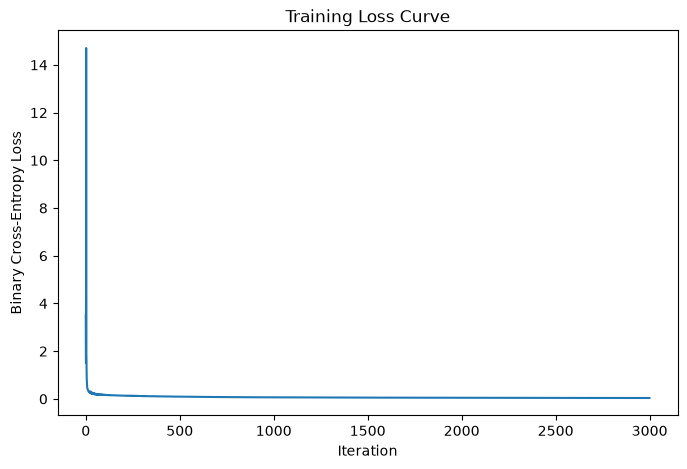

In [51]:
# TODO: train, plot cost history
# Train the neural network
W1, b1, W2, b2, cost_history = train_network(
    X_train,
    y_train,
    n_hidden=64,
    learning_rate=0.005,
    n_iterations=3000
)

# Plot the loss curve
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Curve")

plt.show()



## 10. Evaluate

Reuse your Stage 5 toolkit on the validation set: accuracy, precision, recall, F1, confusion matrix.

Min probability: 0.3466955602617761
Max probability: 0.5246911402286657
Mean probability: 0.48885525801671853
Confusion Matrix:
[[9221  208]
 [  83  988]]
Precision: 0.8260869565217391
Recall: 0.9225023342670402
F1: 0.8716365240405822


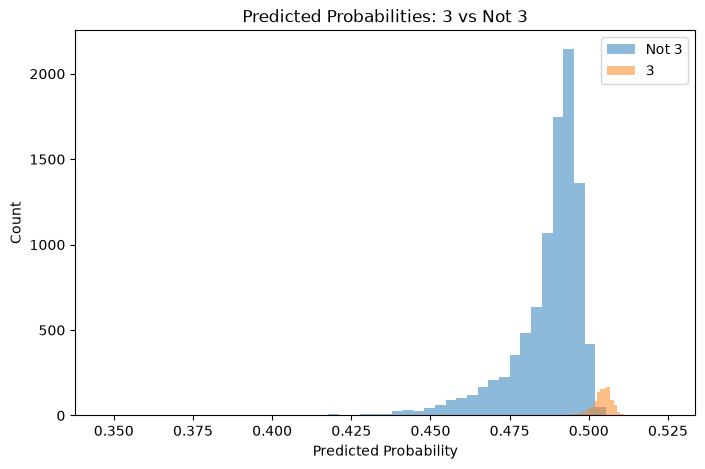

In [50]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# TODO: forward_propagation on X_val, threshold at 0.5, evaluate


A2 = forward_propagation(X_val,W1, b1, W2, b2)

# Convert probabilities into binary predictions
print("Min probability:", A2.min())
print("Max probability:", A2.max())
print("Mean probability:", A2.mean())
y_val_pred = (A2 >= 0.5).astype(int)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))


plt.figure(figsize=(8, 5))

plt.hist(
    A2[y_val.flatten() == 0],
    bins=50,
    alpha=0.5,
    label="Not 3"
)

plt.hist(
    A2[y_val.flatten() == 1],
    bins=50,
    alpha=0.5,
    label="3"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities: 3 vs Not 3")
plt.legend()
plt.show()


## Wrap-up

Write a short summary:
- Walk through, in your own words, what backpropagation actually computes and why the chain rule is the mechanism that makes it possible
- What was the single hardest part of implementing this — getting the matrix shapes right, deriving the gradients, or something else?
- Compare this training loop's structure to linear regression's from Stage 4. What's structurally identical, and what's genuinely new?

- Backpropagation computes the how wrong our final prediction was and how much did each individual weight contribute to that error. Chain rule is the mechanism that makes it possible becuase a neural network is essentially a composition of functions: each layer takes the output of the previous layer and transforms it. T he loss doesn't directly depend on w. It depends on a, which depends on z, which depends on w. The chain rule lets us connect those pieces. We start from our loss and all the way back to our weights.

- The most difficult part of implementing this was understanding what backpropagation was doing at every step from loss, to the hidden layers, to the beginning of our input layer. I learned that starting from loss, we obtain dz2  and dw2 and then dz1 and dw1, afterwards we update our gradient and repeat the steps from forward->backwards->UPDATE.

- From stage 4, the math is similar to linear regressions loop structure, but in this scenario we are dealing with backpropagation which requires more parameters than before. The backward pass is a chain of gradients flowing through a hidden layer, rather than one direct gradient computation.
